In [1]:
# Nguyễn Hoàng Tùng

import pandas as pd
import numpy as np
import random
import os

# 1. Create folder if not exists
os.makedirs("C:/DATA", exist_ok=True)

# 2. Define number of samples and features
n_samples = 10000

# 3. Generate synthetic data
np.random.seed(42)  # for reproducibility

# Jobs (choose from a fixed list)
jobs = ["Engineer", "Doctor", "Teacher", "Farmer", "Driver", "Nurse",
        "IT Specialist", "Lawyer", "Artist", "Student"]

# Areas (urban, rural, suburban)
areas = ["Urban", "Rural", "Suburban"]

# Diet type
diets = ["Balanced", "High-Protein", "Vegetarian", "Keto", "Low-Carb", "Fast-Food"]

data = {
    "Person_ID": range(1, n_samples+1),
    "Age": np.random.randint(18, 70, n_samples),               # age between 18–70
    "Gender": np.random.choice(["Male", "Female"], n_samples), # gender
    "Height_cm": np.random.normal(170, 10, n_samples).astype(int),  # height ~ N(170,10)
    "Weight_kg": np.random.normal(70, 15, n_samples).astype(int),   # weight ~ N(70,15)
    "Job": np.random.choice(jobs, n_samples),
    "Area": np.random.choice(areas, n_samples),
    "Diet": np.random.choice(diets, n_samples),
    "Exercise_Hours_per_Week": np.random.randint(0, 15, n_samples),
    "Sleep_Hours_per_Day": np.random.randint(4, 10, n_samples),
    "Smoking": np.random.choice(["Yes", "No"], n_samples, p=[0.2, 0.8]),
    "Alcohol": np.random.choice(["Yes", "No"], n_samples, p=[0.3, 0.7]),
    "Cholesterol_Level": np.random.randint(150, 280, n_samples),
    "Blood_Pressure": np.random.randint(90, 160, n_samples),
    "Diabetes": np.random.choice(["Yes", "No"], n_samples, p=[0.1, 0.9]),
    "Daily_Calories": np.random.randint(1500, 4000, n_samples),
    "Steps_per_Day": np.random.randint(1000, 20000, n_samples),
    "Screen_Time_Hours": np.random.randint(1, 12, n_samples),
    "Stress_Level": np.random.randint(1, 10, n_samples),  # 1 = low, 10 = high
    "Family_History": np.random.choice(["Yes", "No"], n_samples, p=[0.3, 0.7])
}

# 4. Convert dictionary → DataFrame
df = pd.DataFrame(data)

# 5. Save dataset to CSV
output_path = "D:/PTIT/20251/IntSys/data_4.2.csv"
df.to_csv(output_path, index=False)

print(f"Dataset created and saved at {output_path}")
print(df.head())


Dataset created and saved at D:/PTIT/20251/IntSys/data_4.2.csv
   Person_ID  Age  Gender  Height_cm  Weight_kg            Job      Area  \
0          1   56    Male        166         57        Teacher     Rural   
1          2   69  Female        163         57  IT Specialist  Suburban   
2          3   46  Female        165         66        Student     Urban   
3          4   32  Female        179         62          Nurse     Rural   
4          5   60    Male        177         69  IT Specialist     Rural   

         Diet  Exercise_Hours_per_Week  Sleep_Hours_per_Day Smoking Alcohol  \
0   Fast-Food                       14                    5      No     Yes   
1   Fast-Food                        2                    8      No     Yes   
2        Keto                       14                    7      No      No   
3   Fast-Food                        5                    8      No     Yes   
4  Vegetarian                        8                    6     Yes     Yes   

   Ch

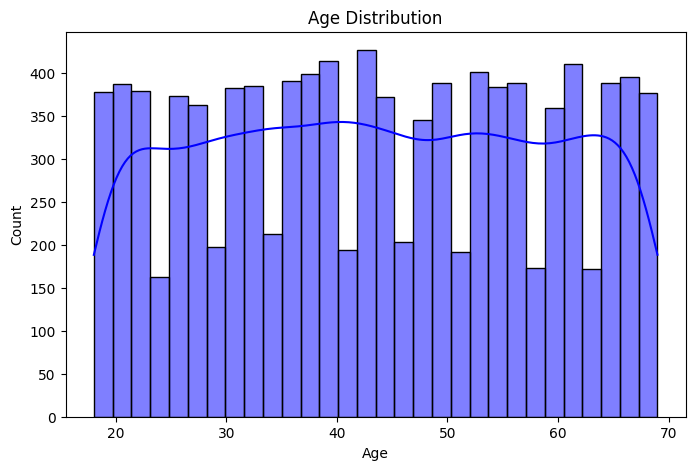

C:\Users\Admin\AppData\Local\Temp\ipykernel_9160\2832299150.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Gender", data=df, palette="Set2")


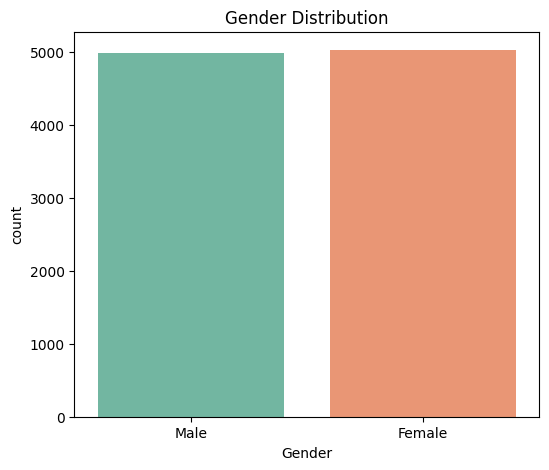

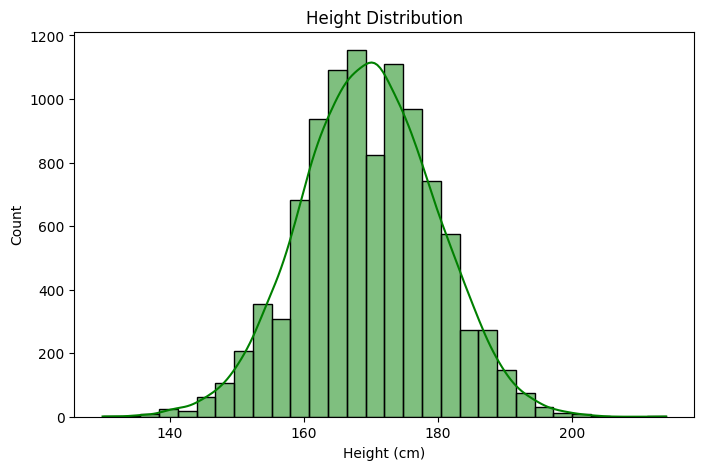

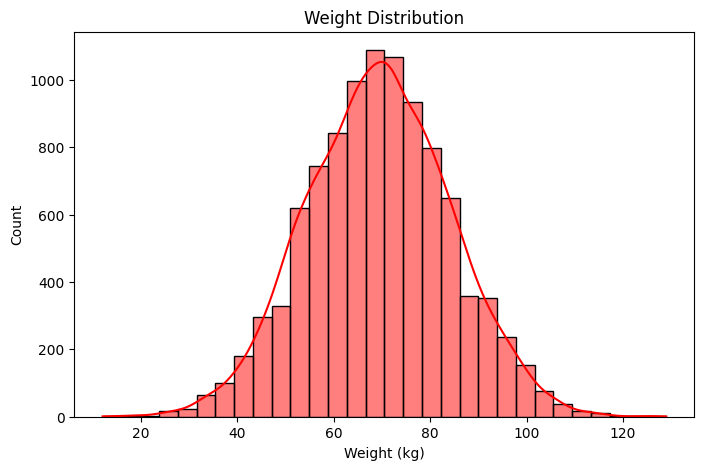

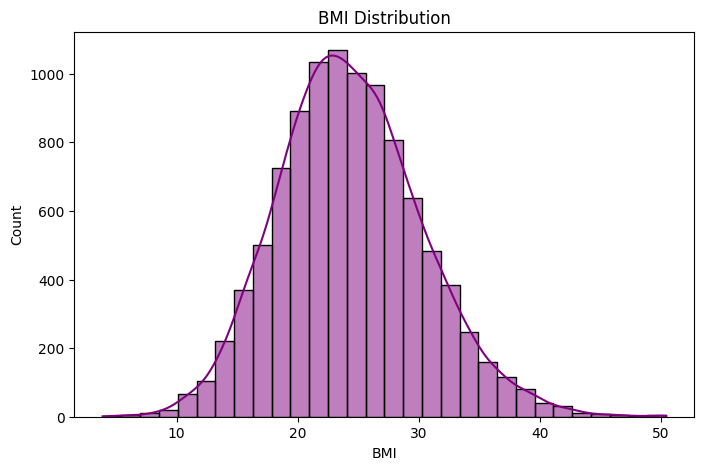

C:\Users\Admin\AppData\Local\Temp\ipykernel_9160\2832299150.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="Job", data=df, order=df["Job"].value_counts().index, palette="coolwarm")


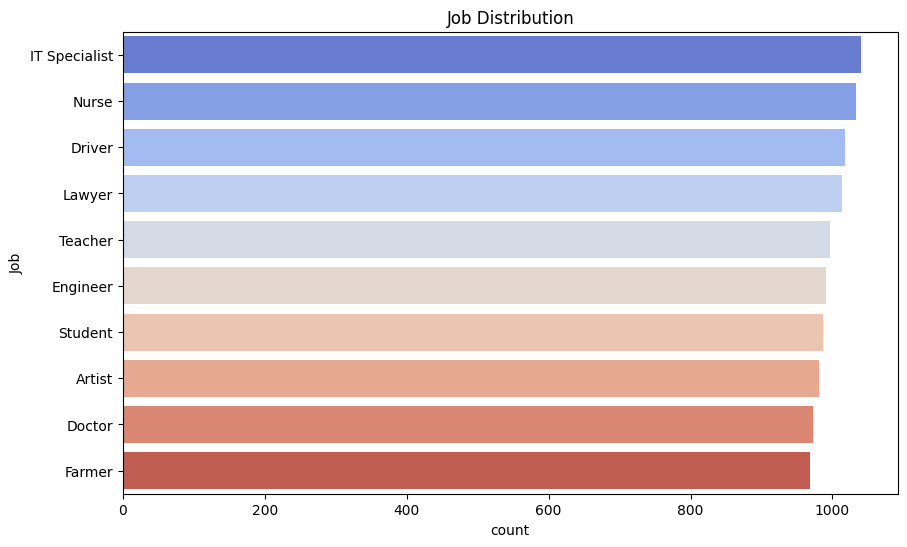

In [2]:
# Nguyễn Hoàng Tùng

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load dataset
df = pd.read_csv("D:/PTIT/20251/IntSys/data_4.2.csv")

# 2. Create BMI column
df["BMI"] = df["Weight_kg"] / ((df["Height_cm"]/100) ** 2)

# 3. Plot Age distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=30, kde=True, color="blue")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# 4. Plot Gender distribution
plt.figure(figsize=(6,5))
sns.countplot(x="Gender", data=df, palette="Set2")
plt.title("Gender Distribution")
plt.show()

# 5. Plot Height distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Height_cm"], bins=30, kde=True, color="green")
plt.title("Height Distribution")
plt.xlabel("Height (cm)")
plt.show()

# 6. Plot Weight distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Weight_kg"], bins=30, kde=True, color="red")
plt.title("Weight Distribution")
plt.xlabel("Weight (kg)")
plt.show()

# 7. Plot BMI distribution
plt.figure(figsize=(8,5))
sns.histplot(df["BMI"], bins=30, kde=True, color="purple")
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.show()

# 8. Plot Job distribution
plt.figure(figsize=(10,6))
sns.countplot(y="Job", data=df, order=df["Job"].value_counts().index, palette="coolwarm")
plt.title("Job Distribution")
plt.show()


In [3]:
# Nguyễn Hoàng Tùng

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# 1. Load dataset
df = pd.read_csv("D:/PTIT/20251/IntSys/data_4.2.csv")

# 2. Compute BMI
df["BMI"] = df["Weight_kg"] / ((df["Height_cm"]/100) ** 2)

# 3. Create BMI Category
def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    else:
        return "Overweight"

df["BMI_Category"] = df["BMI"].apply(bmi_category)

# 4. Encode categorical features
categorical_cols = ["Gender", "Job", "Area", "Diet", "Smoking", "Alcohol", "Diabetes", "Family_History"]
encoder = LabelEncoder()
for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

# 5. Select features (exclude Person_ID, BMI, BMI_Category)
X = df.drop(columns=["Person_ID", "BMI", "BMI_Category"])
y = df["BMI_Category"]

# 6. Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 7. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# 8. Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

# 9. Train & Evaluate
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"\n{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))



Logistic Regression Accuracy: 0.9870
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.98       813
  Overweight       0.99      0.99      0.99       871
 Underweight       0.98      0.97      0.98       316

    accuracy                           0.99      2000
   macro avg       0.99      0.98      0.98      2000
weighted avg       0.99      0.99      0.99      2000


Decision Tree Accuracy: 0.9850
              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98       813
  Overweight       1.00      1.00      1.00       871
 Underweight       0.96      0.97      0.96       316

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.99      0.98      0.99      2000


Random Forest Accuracy: 0.9745
              precision    recall  f1-score   support

      Normal       0.95      0.99      0.97       813
  Overweight       0.99    

C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framewo

Train: (6400, 19, 1) (6400, 3)
Val:   (1600, 19, 1) (1600, 3)
Test:  (2000, 19, 1) (2000, 3)
Epoch 1/50


C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5763 - loss: 0.8571 - val_accuracy: 0.7256 - val_loss: 0.6205
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7159 - loss: 0.6271 - val_accuracy: 0.8087 - val_loss: 0.4850
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7584 - loss: 0.5422 - val_accuracy: 0.8256 - val_loss: 0.4288
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7764 - loss: 0.5107 - val_accuracy: 0.8381 - val_loss: 0.3957
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7975 - loss: 0.4688 - val_accuracy: 0.8494 - val_loss: 0.3761
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8094 - loss: 0.4478 - val_accuracy: 0.8700 - val_loss: 0.3417
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8220 - loss: 0.4164 - val_accuracy: 0.8813 - val_loss: 0.3139
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8380 - loss: 0.3918 - val_accuracy: 0.8863 - val_

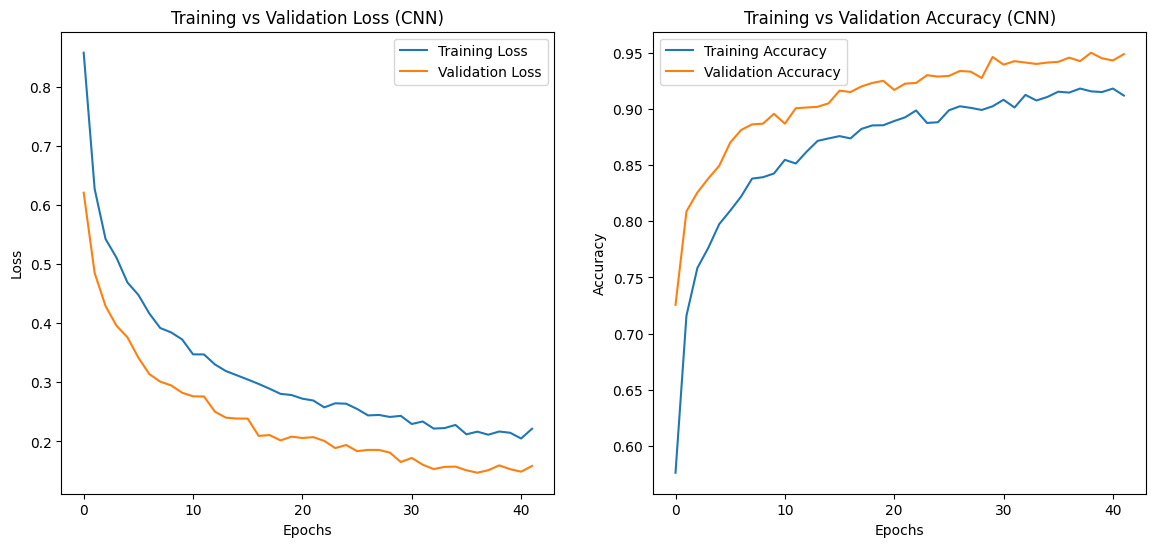

📊 Train Loss: 0.2215
📊 Val Loss:   0.1586
📈 Train Acc: 0.9119
📈 Val Acc:   0.9488

=== Overfitting Check ===
✅ Well-generalized model

Training RNN...
Epoch 1/10


C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7844 - loss: 0.4739 - val_accuracy: 0.9312 - val_loss: 0.1767
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9022 - loss: 0.2261 - val_accuracy: 0.9475 - val_loss: 0.1368
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9236 - loss: 0.1784 - val_accuracy: 0.9406 - val_loss: 0.1363
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9314 - loss: 0.1644 - val_accuracy: 0.9444 - val_loss: 0.1281
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9358 - loss: 0.1573 - val_accuracy: 0.9525 - val_loss: 0.1127
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9445 - loss: 0.1321 - val_accuracy: 0.9494 - val_loss: 0.1198
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9472 - loss: 0.1241 - val_accuracy: 0.9581 - val_loss: 0.1127
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9502 - loss: 0.1199 - val_accuracy: 0.9594 - val

In [4]:
# Nguyễn Hoàng Tùng

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, Flatten, SimpleRNN, LSTM, MaxPooling1D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# ==========================
# 1. Load dataset
# ==========================
df = pd.read_csv("D:/PTIT/20251/IntSys/data_4.2.csv")

# Compute BMI & Category
df["BMI"] = df["Weight_kg"] / ((df["Height_cm"]/100) ** 2)
def bmi_category(bmi):
    if bmi < 18.5: return "Underweight"
    elif bmi < 25: return "Normal"
    else: return "Overweight"
df["BMI_Category"] = df["BMI"].apply(bmi_category)

# Encode categorical cols
categorical_cols = ["Gender", "Job", "Area", "Diet", "Smoking", "Alcohol", "Diabetes", "Family_History"]
encoder = LabelEncoder()
for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

# Features & Labels
X = df.drop(columns=["Person_ID", "BMI", "BMI_Category"])
y = df["BMI_Category"]

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)  # 0=Normal,1=Overweight,2=Underweight
y_categorical = to_categorical(y_encoded, num_classes=3)

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reshape for deep learning models (samples, timesteps, features)
X_reshaped = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)

# ==========================
# 2. Split Train/Val/Test
# ==========================
# First split train/test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_reshaped, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

# Then split train/validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full.argmax(axis=1)
)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

# ==========================
# 3. Build CNN Model
# ==========================
cnn_model = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])
cnn_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train CNN
history = cnn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

# ==========================
# 4. Plot Training vs Validation
# ==========================
plt.figure(figsize=(14,6))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss (CNN)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training vs Validation Accuracy (CNN)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

# ==========================
# 5. Overfitting Check
# ==========================
final_train_loss = history.history['loss'][-1]
final_val_loss   = history.history['val_loss'][-1]
final_train_acc  = history.history['accuracy'][-1]
final_val_acc    = history.history['val_accuracy'][-1]

print("📊 Train Loss:", round(final_train_loss,4))
print("📊 Val Loss:  ", round(final_val_loss,4))
print("📈 Train Acc:", round(final_train_acc,4))
print("📈 Val Acc:  ", round(final_val_acc,4))

loss_gap = final_val_loss - final_train_loss
acc_gap  = final_train_acc - final_val_acc
print("\n=== Overfitting Check ===")
if acc_gap > 0.15 and loss_gap > 0:
    print("⚠️ Overfitting detected")
elif acc_gap < 0.05 and abs(loss_gap) < 0.1:
    print("✅ Well-generalized model")
else:
    print("ℹ️ Acceptable but monitor further")

# ==========================
# 6. Build RNN Model
# ==========================
rnn_model = Sequential([
    SimpleRNN(64, activation='relu', return_sequences=True, input_shape=(X_train.shape[1],1)),
    Dropout(0.3),
    SimpleRNN(32, activation='relu', return_sequences=True),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])
rnn_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# ==========================
# 7. Build LSTM Model
# ==========================
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1],1)),
    Dropout(0.3),
    LSTM(32, return_sequences=True),
    LSTM(16),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])
lstm_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# ==========================
# 8. Train RNN and LSTM
# ==========================
print("\nTraining RNN...")
rnn_model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_val,y_val), verbose=1)

print("\nTraining LSTM...")
lstm_model.fit(X_train, y_train, epochs=10, batch_size=64, validation_data=(X_val,y_val), verbose=1)

# ==========================
# 9. Evaluate
# ==========================
cnn_acc = cnn_model.evaluate(X_test, y_test, verbose=0)[1]
rnn_acc = rnn_model.evaluate(X_test, y_test, verbose=0)[1]
lstm_acc = lstm_model.evaluate(X_test, y_test, verbose=0)[1]

print(f"\nCNN Accuracy: {cnn_acc:.4f}")
print(f"RNN Accuracy: {rnn_acc:.4f}")
print(f"LSTM Accuracy: {lstm_acc:.4f}")


In [5]:
# Nguyễn Hoàng Tùng

from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score
import numpy as np
import pandas as pd

# ==========================
# 0. Ensure we have both datasets
# ==========================
# X_scaled, y (string labels) -> for ML models
# X_reshaped, y_categorical, y_encoded -> for DL models

X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# For DL we already have: X_train, X_test, y_train, y_test (one-hot encoded)

y_test_labels = np.argmax(y_test, axis=1)  # integer labels for DL

# ==========================
# Helper function
# ==========================
def evaluate_model(name, y_true, y_pred):
    # Convert labels if necessary
    if isinstance(y_true[0], str):  # sklearn models
        acc = accuracy_score(y_true, y_pred)
        mae = mean_absolute_error(
            LabelEncoder().fit_transform(y_true),
            LabelEncoder().fit_transform(y_pred)
        )
        mse = mean_squared_error(
            LabelEncoder().fit_transform(y_true),
            LabelEncoder().fit_transform(y_pred)
        )
    else:  # deep learning integer labels
        acc = accuracy_score(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        mse = mean_squared_error(y_true, y_pred)

    rmse = np.sqrt(mse)
    return {"Model": name, "Accuracy": acc, "MAE": mae, "MSE": mse, "RMSE": rmse}

results_list = []

# ==========================
# 1. Evaluate Basic ML Models (2D data)
# ==========================
for name, model in models.items():
    y_pred = model.predict(X_test_ml)
    results_list.append(evaluate_model(name, y_test_ml.tolist(), y_pred.tolist()))

# ==========================
# 2. Evaluate Deep Learning Models (3D data)
# ==========================
cnn_pred = np.argmax(cnn_model.predict(X_test), axis=1)
rnn_pred = np.argmax(rnn_model.predict(X_test), axis=1)
lstm_pred = np.argmax(lstm_model.predict(X_test), axis=1)

results_list.append(evaluate_model("CNN", y_test_labels, cnn_pred))
results_list.append(evaluate_model("RNN", y_test_labels, rnn_pred))
results_list.append(evaluate_model("LSTM", y_test_labels, lstm_pred))

# ==========================
# 3. Create Comparison Table
# ==========================
results_df = pd.DataFrame(results_list)
print("\n📊 Model Evaluation Results:")
print(results_df)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

📊 Model Evaluation Results:
                 Model  Accuracy     MAE     MSE      RMSE
0  Logistic Regression    0.9870  0.0205  0.0355  0.188414
1        Decision Tree    0.9850  0.0265  0.0495  0.222486
2        Random Forest    0.9745  0.0430  0.0780  0.279285
3                  SVM    0.9530  0.0735  0.1265  0.355668
4                  KNN    0.6855  0.4300  0.6610  0.813019
5                  CNN    0.9500  0.0625  0.0875  0.295804
6                  RNN    0.9595  0.0690  0.1260  0.354965
7                 LSTM    0.5295  0.5135  0.5995  0.774274


C:\Users\Admin\AppData\Local\Temp\ipykernel_9160\1252296269.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y=metric, data=results_df, palette="viridis")
C:\Users\Admin\AppData\Local\Temp\ipykernel_9160\1252296269.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y=metric, data=results_df, palette="viridis")
C:\Users\Admin\AppData\Local\Temp\ipykernel_9160\1252296269.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y=metric, data=results_df, palette="viridis")
C:\Users\Admin\AppData\Local\Temp\ipy

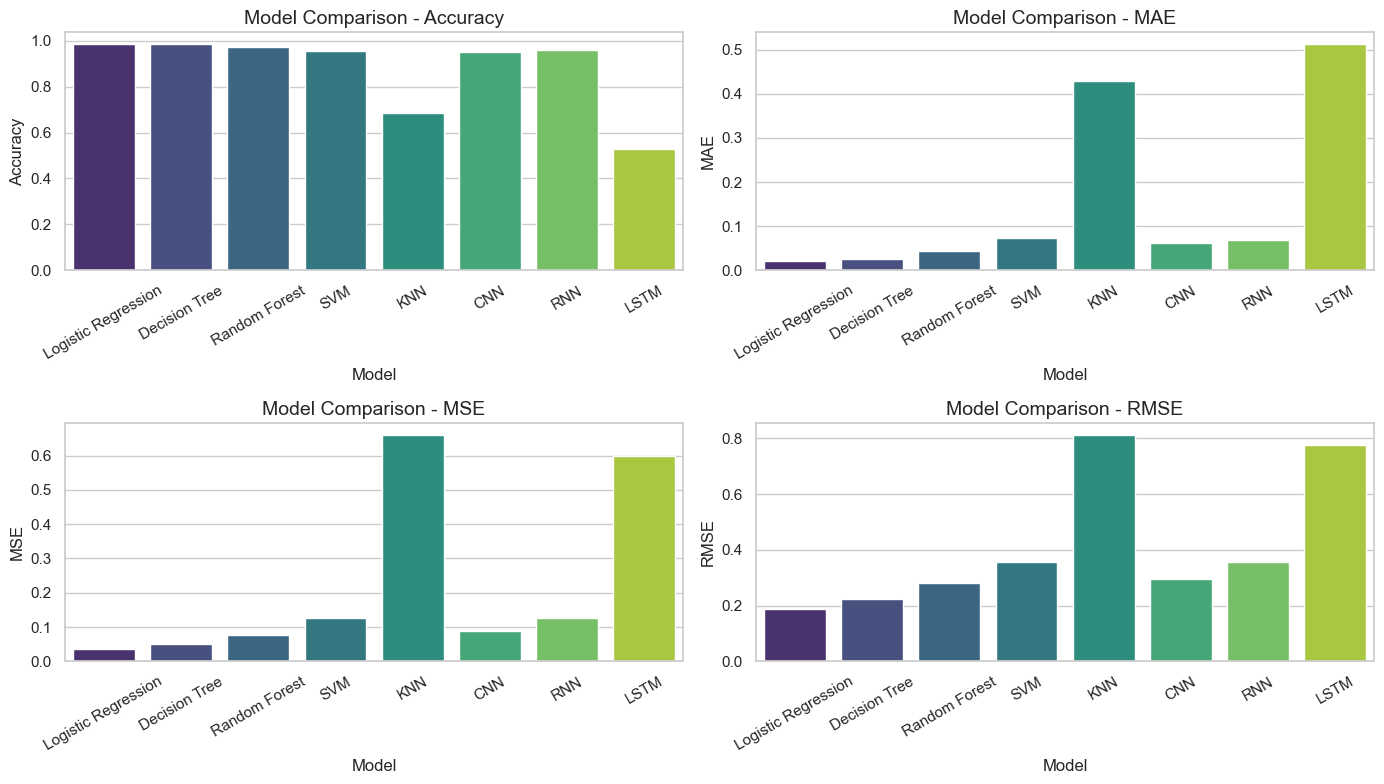

In [6]:
# Nguyễn Hoàng Tùng

import matplotlib.pyplot as plt
import seaborn as sns

# Ensure we use the results from part (e)
metrics = ["Accuracy", "MAE", "MSE", "RMSE"]

# Set plot style
sns.set(style="whitegrid")
plt.figure(figsize=(14, 8))

# Plot each metric
for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    sns.barplot(x="Model", y=metric, data=results_df, palette="viridis")
    plt.title(f"Model Comparison - {metric}", fontsize=14)
    plt.xticks(rotation=30)
    plt.ylabel(metric)

plt.tight_layout()
plt.show()


In [ ]:
# Nguyễn Hoàng Tùng

from flask import Flask, request, render_template_string
import numpy as np
import pandas as pd
import joblib
from tensorflow.keras.models import load_model

# --------------------------
# 1. Load dataset to get exact column names
# --------------------------
df = pd.read_csv(r"D:/PTIT/20251/IntSys/data_4.2.csv")
print("✅ Columns in dataset:", df.columns.tolist())

# Detect label column automatically (last column assumed as target)
TARGET_COL = df.columns[-1]
RAW_COLUMNS = df.drop(TARGET_COL, axis=1).columns.tolist()
print("✅ Using feature columns:", RAW_COLUMNS)
print("✅ Target column:", TARGET_COL)

# --------------------------
# 2. Load best model
# --------------------------
try:
        model = joblib.load("best_model.pkl")
except Exception as e:
    print("⚠️ Could not load model:", e)

# --------------------------
# 3. Define labels (adjust if your dataset has more/different classes)
# --------------------------
labels = df[TARGET_COL].unique().tolist()
print("✅ Labels:", labels)

# --------------------------
# 4. Flask app setup
# --------------------------
app = Flask(__name__)

def predict_health_status(features):
    # Create DataFrame with same columns as training data
    features_df = pd.DataFrame([features], columns=RAW_COLUMNS)

    if best_model_name in ["CNN", "RNN", "LSTM"]:
        features_3d = features_df.values.reshape(features_df.shape[0], features_df.shape[1], 1)
        pred = np.argmax(model.predict(features_3d), axis=1)[0]
    else:
        pred = model.predict(features_df.values)
        # Handle sklearn vs keras output
        if hasattr(pred, "argmax"):
            pred = pred.argmax(axis=1)[0]
        else:
            pred = int(pred[0])
    return labels[pred]

# --------------------------
# 5. Simple HTML UI
# --------------------------
HTML_PAGE = """
<!DOCTYPE html>
<html>
<head>
    <title>Health Prediction</title>
    <style>
        body { font-family: Arial; margin: 20px; }
        .container { width: 500px; margin: auto; }
        label { display: block; margin-top: 10px; }
        input { width: 100%; padding: 8px; margin-top: 5px; }
        button { margin-top: 15px; padding: 10px; width: 100%; }
        .result { margin-top: 20px; font-weight: bold; color: green; }
    </style>
</head>
<body>
<div class="container">
    <h2>🏥 Health Status Prediction</h2>
    <form method="POST">
        {% for col in columns %}
        <label>{{col}}</label>
        <input type="text" name="{{col}}" required>
        {% endfor %}
        <button type="submit">Predict</button>
    </form>
    {% if result %}
    <div class="result">✅ Prediction: {{ result }}</div>
    {% endif %}
</div>
</body>
</html>
"""

@app.route("/", methods=["GET", "POST"])
def index():
    result = None
    if request.method == "POST":
        inputs = []
        for col in RAW_COLUMNS:
            val = request.form[col]
            try:
                inputs.append(float(val))
            except:
                inputs.append(val)  # keep string for categorical
        result = predict_health_status(inputs)
    return render_template_string(HTML_PAGE, columns=RAW_COLUMNS, result=result)

# --------------------------
# 6. Run Flask inside Jupyter
# --------------------------
from werkzeug.serving import run_simple

print("🚀 Starting Flask app... Visit http://127.0.0.1:5000 in your browser.")
run_simple('localhost', 5000, app)


C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framewo

✅ Columns in dataset: ['Person_ID', 'Age', 'Gender', 'Height_cm', 'Weight_kg', 'Job', 'Area', 'Diet', 'Exercise_Hours_per_Week', 'Sleep_Hours_per_Day', 'Smoking', 'Alcohol', 'Cholesterol_Level', 'Blood_Pressure', 'Diabetes', 'Daily_Calories', 'Steps_per_Day', 'Screen_Time_Hours', 'Stress_Level', 'Family_History']
✅ Using feature columns: ['Person_ID', 'Age', 'Gender', 'Height_cm', 'Weight_kg', 'Job', 'Area', 'Diet', 'Exercise_Hours_per_Week', 'Sleep_Hours_per_Day', 'Smoking', 'Alcohol', 'Cholesterol_Level', 'Blood_Pressure', 'Diabetes', 'Daily_Calories', 'Steps_per_Day', 'Screen_Time_Hours', 'Stress_Level']
✅ Target column: Family_History
✅ Labels: ['No', 'Yes']
🚀 Starting Flask app... Visit http://127.0.0.1:5000 in your browser.


127.0.0.1 - - [02/Oct/2025 14:17:26] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [02/Oct/2025 14:17:26] "GET /favicon.ico HTTP/1.1" 404 -
[2025-10-02 14:17:33,337] ERROR in app: Exception on / [POST]
Traceback (most recent call last):
  File "C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\flask\app.py", line 1511, in wsgi_app
    response = self.full_dispatch_request()
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\flask\app.py", line 919, in full_dispatch_request
    rv = self.handle_user_exception(e)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\flask\app.py", line 917, in full_dispatch_request
    rv = self.dispatch_request()
         ^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\flask\app.py", line 902, in dispatch_request
    return self.ensure_sync(self.

In [11]:
# Nguyễn Hoàng Tùng

import json
import random
import math
from itertools import product
from datetime import datetime

random.seed(42)

OUTPATH = r"D:\PTIT\20251\IntSys\kb_healthGuide.json"

# --- Configuration: tune these to change KB size ---
# small sections
n_bmi_steps = 301   # BMI from 10.0 to 40.0 by 0.1 -> 301 entries
n_waist_entries = 200  # waist rules by age/gender groups
diseases = [
    {
        "name": "Type 2 Diabetes",
        "risk_factors": ["BMI >= 25", "waist > threshold", "family_history"],
        "diet_recommendations": ["Limit simple carbs", "Choose whole grains"],
        "exercise_recommendations": ["Brisk walk 30 min daily"]
    },
    {
        "name": "Hypertension",
        "diet_recommendations": ["DASH diet", "Limit sodium <5g/day"],
        "exercise_recommendations": ["Moderate cardio 30 min, most days"]
    },
    {
        "name": "Hyperlipidemia",
        "diet_recommendations": ["Limit saturated fat", "Increase fiber"],
        "exercise_recommendations": ["Aerobic exercise 30-60 min"]
    }
]  # small list

n_food_items = 5000  # synthetic food list size
n_exercises = 300    # exercise entries

# big sections (this will be the main driver to reach 3M)
n_mealplans = 120000   # number of generated meal plans
n_rules_target = 3000000 - (n_bmi_steps + n_waist_entries + len(diseases) + n_food_items + n_mealplans + n_exercises)
# ensure non-negative
if n_rules_target < 0:
    n_rules_target = 1_000_000

# --- Utility generators ---
def gen_bmi_classification():
    """
    Yield BMI classification entries with fine-grained thresholds (0.1 steps).
    """
    for i in range(n_bmi_steps):
        bmi = round(10.0 + 0.1 * i, 1)
        if bmi < 18.5:
            label = "Underweight"
            advice = ["Increase calorie intake with healthy foods", "Resistance training 2-3x/week"]
        elif bmi < 25:
            label = "Normal"
            advice = ["Maintain balanced diet", "150 min moderate exercise/week"]
        elif bmi < 30:
            label = "Overweight"
            advice = ["Reduce calorie intake moderately", "Increase aerobic activity"]
        else:
            label = "Obese"
            advice = ["Medical evaluation", "Structured weight loss program"]
        yield {"bmi": bmi, "category": label, "advice": advice}

def gen_waist_risk():
    """
    Waist risk entries stratified by age and gender.
    """
    age_groups = [(18,30),(31,40),(41,50),(51,60),(61,80)]
    genders = ["Male","Female"]
    for gender in genders:
        for (a,b) in age_groups:
            # threshold example
            threshold = 94 if gender=="Male" else 80
            yield {
                "gender": gender,
                "age_range": f"{a}-{b}",
                "waist_threshold_cm": threshold,
                "risk": "Increased risk if waist > threshold",
                "advice": ["Measure waist at navel", "Aim to reduce abdominal fat"]
            }

def gen_food_items():
    """
    Create synthetic food items; ideally one would import USDA data but we synthesize.
    """
    categories = ["Grains","Vegetable","Fruit","Meat","Fish","Dairy","Nuts","Beverage","Snack"]
    grain_names = ["rice","bread","oats","quinoa","pasta","barley"]
    vegs = ["spinach","broccoli","carrot","tomato","pepper","cucumber"]
    fruits = ["apple","banana","orange","berries","mango","pear"]
    meats = ["chicken","beef","pork","lamb","turkey"]
    fish = ["salmon","tuna","mackerel","cod"]
    dairy = ["milk","yogurt","cheese"]
    nuts = ["almond","walnut","peanut"]
    beverages = ["coffee","tea","soda","juice"]
    snacks = ["chips","cookie","chocolate"]
    pools = [grain_names, vegs, fruits, meats, fish, dairy, nuts, beverages, snacks]

    created = 0
    idx = 0
    while created < n_food_items:
        cat_index = idx % len(pools)
        pool = pools[cat_index]
        name = random.choice(pool)
        variant = random.choice(["plain","roasted","salted","fresh","canned","steamed","grilled","baked"])
        full_name = f"{variant} {name}"
        calories = random.randint(20, 700)
        protein = round(random.uniform(0.0, 40.0),1)
        fat = round(random.uniform(0.0, 50.0),1)
        carbs = max(0, round((calories - protein*4 - fat*9)/4,1))
        gly_index = random.randint(10,95)
        advice = []
        if calories > 400:
            advice.append("High calorie — moderate portion")
        if gly_index > 70:
            advice.append("High GI — avoid for weight loss")
        yield {
            "id": f"food_{created+1}",
            "name": full_name,
            "category": categories[cat_index],
            "calories_per_100g": calories,
            "protein_g": protein,
            "fat_g": fat,
            "carbs_g": carbs,
            "glycemic_index": gly_index,
            "advice": advice
        }
        created += 1
        idx += 1

def gen_exercises():
    base = [
        ("Walking", 150), ("Running", 400), ("Cycling", 350), ("Swimming", 370),
        ("Squat", 120), ("Deadlift", 200), ("Push-ups", 100), ("Yoga", 80),
        ("HIIT", 500), ("Rowing", 420)
    ]
    # expand to n_exercises
    for i in range(n_exercises):
        name, burn = random.choice(base)
        variant = random.choice(["light", "moderate", "intense", "beginner", "advanced"])
        yield {
            "id": f"ex_{i+1}",
            "name": f"{variant} {name}",
            "calories_burned_per_30min": max(10, int(burn * random.uniform(0.6,1.4))),
            "difficulty": random.choice(["Easy","Moderate","Hard"]),
            "suitable_BMI_range": f"{random.randint(15,20)}-{random.randint(21,40)}"
        }

def gen_meal_plans(food_ids):
    """
    Generate meal plans by combining 3-5 food items to reach calorie targets
    We'll create n_mealplans entries.
    """
    cal_targets = [1200, 1500, 1800, 2000, 2200, 2500]
    diets = ["Balanced","Low-carb","High-protein","Vegetarian","Keto","Mediterranean"]
    created = 0
    max_food = len(food_ids)
    while created < n_mealplans:
        k = random.randint(3,5)
        picks = [random.choice(food_ids) for _ in range(k)]
        target = random.choice(cal_targets)
        diet = random.choice(diets)
        # estimate calories by summing chosen foods' calories (we only have ids here)
        plan = {
            "id": f"mealplan_{created+1}",
            "foods": picks,
            "target_calories": target,
            "diet_type": diet,
            "advice": [f"Follow {diet} pattern", "Adjust portions to meet calorie target"]
        }
        yield plan
        created += 1

def gen_rules(bmi_step_count, age_groups, genders, diseases_list, activities, n_rules):
    """
    Generate 'n_rules' rules combinatorically.
    A rule is small JSON dict with conditions and advice.
    """
    created = 0
    # pool of possible phrase fragments
    bmi_indices = list(range(bmi_step_count))  # each index corresponds to a BMI step
    while created < n_rules:
        bmi_idx = random.choice(bmi_indices)
        age = random.choice(age_groups)
        gender = random.choice(genders)
        disease = random.choice(diseases_list)["name"]
        activity = random.choice(activities)
        # create conditions using these
        bmi_value = round(10.0 + 0.1 * bmi_idx, 1)
        cond = {
            "BMI": f"{bmi_value}",
            "age": f"{age[0]}-{age[1]}",
            "gender": gender,
            "disease": disease if random.random() < 0.15 else None,
            "activity_level": activity
        }
        advice = []
        if bmi_value >= 30:
            advice.append("High risk: recommend clinical weight loss program")
            advice.append("Reduce refined carbs and added sugars")
        elif bmi_value >= 25:
            advice.append("Reduce portion size, increase activity")
        elif bmi_value < 18.5:
            advice.append("Increase calorie-dense healthy foods")
        else:
            advice.append("Maintain healthy lifestyle")
        # possibly add exercise/diet specifics
        if "High" in activity:
            advice.append("Include resistance training 2x/week")
        rule = {
            "id": f"rule_{created+1}",
            "if": {k:v for k,v in cond.items() if v is not None},
            "then": {
                "risk": "elevated" if bmi_value>=25 else "normal",
                "advice": advice
            }
        }
        created += 1
        yield rule

# --- Now stream-write the big JSON object with arrays ---
def build_kb_json(outpath=OUTPATH):
    print("Starting KB build:", datetime.now().isoformat())
    with open(outpath, "w", encoding="utf-8") as f:
        f.write("{\n")
        # 1. BMI_Classification
        f.write('"BMI_Classification": [\n')
        first = True
        for item in gen_bmi_classification():
            if not first:
                f.write(",\n")
            f.write(json.dumps(item, ensure_ascii=False))
            first = False
        f.write("\n],\n")

        # 2. Waist_Risk
        f.write('"Waist_Risk": [\n')
        first = True
        for item in gen_waist_risk():
            if not first:
                f.write(",\n")
            f.write(json.dumps(item, ensure_ascii=False))
            first = False
        f.write("\n],\n")

        # 3. Diseases
        f.write('"Diseases": [\n')
        f.write(",\n".join(json.dumps(d, ensure_ascii=False) for d in diseases))
        f.write("\n],\n")

        # 4. Foods
        f.write('"Foods": [\n')
        food_ids = []
        first = True
        for food in gen_food_items():
            if not first:
                f.write(",\n")
            f.write(json.dumps(food, ensure_ascii=False))
            food_ids.append(food["id"])
            first = False
        f.write("\n],\n")

        # 5. Meal_Plans
        f.write('"Meal_Plans": [\n')
        first = True
        for mp in gen_meal_plans(food_ids):
            if not first:
                f.write(",\n")
            f.write(json.dumps(mp, ensure_ascii=False))
            first = False
        f.write("\n],\n")

        # 6. Exercise
        f.write('"Exercise": [\n')
        first = True
        for ex in gen_exercises():
            if not first:
                f.write(",\n")
            f.write(json.dumps(ex, ensure_ascii=False))
            first = False
        f.write("\n],\n")

        # 7. Rules (this is the heavy part)
        print("Writing rules (this may take a while)...")
        f.write('"Rules": [\n')
        first = True
        # define pools for rules generation
        age_groups = [(18,30),(31,40),(41,50),(51,60),(61,80)]
        genders = ["Male","Female"]
        activities = ["Low","Moderate","High","Very High"]

        rule_gen = gen_rules(n_bmi_steps, age_groups, genders, diseases, activities, n_rules_target)
        chunk = 0
        for rule in rule_gen:
            if not first:
                f.write(",\n")
            f.write(json.dumps(rule, ensure_ascii=False))
            first = False
            chunk += 1
            if chunk % 100000 == 0:
                print(f"  - written {chunk} rules at {datetime.now().isoformat()}")
        f.write("\n]\n")  # close Rules
        f.write("}\n")  # close root object
    print("Finished KB build:", datetime.now().isoformat())
    print("Saved to:", outpath)

# --- Simple KB query to produce a short health guide for a user ---
def generate_health_guide(user_profile, metrics_df=None, kb_path=OUTPATH, max_rules_to_scan=100000):
    """
    user_profile: dict with keys including 'age', 'gender', 'BMI', 'disease' (optional), 'activity_level'
    metrics_df: pandas DataFrame with model metrics (from Part F) to include in the guide
    This function streams through the Rules in the KB and returns matching advice (first matches).
    NOTE: streaming large JSON is slower; we scan Rules only to avoid loading entire KB.
    """
    matches = []
    advice_set = []
    target_bmi = user_profile.get("BMI", None)
    target_age = user_profile.get("age", None)
    target_gender = user_profile.get("gender", None)
    target_disease = user_profile.get("disease", None)
    target_activity = user_profile.get("activity_level", None)

    # We'll parse the JSON file and locate "Rules" array start, then stream-read rules line by line.
    found_rules = 0
    with open(kb_path, "r", encoding="utf-8") as f:
        # Find the start of the "Rules" array
        for line in f:
            if '"Rules": [' in line:
                break
        # Now read subsequent lines until the end of array ']\n'
        for line in f:
            s = line.strip()
            if s.startswith(']'):
                break
            # remove trailing commas
            if s.endswith(','):
                s = s[:-1]
            if not s:
                continue
            try:
                rule = json.loads(s)
            except Exception:
                # if object spans multiple lines, try to read full object
                # accumulate until balanced braces
                obj_lines = [s]
                braces = s.count("{") - s.count("}")
                while braces > 0:
                    nxt = next(f)
                    obj_lines.append(nxt)
                    braces += nxt.count("{") - nxt.count("}")
                obj_text = "".join(obj_lines)
                rule = json.loads(obj_text.rstrip().rstrip(","))
            found_rules += 1
            # check simple matching
            cond = rule.get("if", {})
            ok = True
            if target_bmi is not None and "BMI" in cond:
                try:
                    # cond BMI stored as string like "24.5"
                    cond_bmi = float(cond["BMI"])
                    # allow +/- 0.5 tolerance
                    if abs(cond_bmi - target_bmi) > 1.0:
                        ok = False
                except:
                    pass
            if ok and target_age is not None and "age" in cond:
                lo,hi = map(int, cond["age"].split("-"))
                if not (lo <= target_age <= hi):
                    ok = False
            if ok and target_gender is not None and "gender" in cond:
                if cond["gender"] != target_gender:
                    ok = False
            if ok and target_disease is not None and "disease" in cond:
                # only check if disease present and matches
                if cond.get("disease") and cond["disease"] != target_disease:
                    ok = False
            if ok:
                matches.append(rule)
                for t in rule.get("then", {}).get("advice", []):
                    advice_set.append(t)
            if found_rules >= max_rules_to_scan:
                break

    # Compose the guide
    guide = {
        "user_profile": user_profile,
        "summary": f"Found {len(matches)} matching rules (scanned {found_rules}).",
        "top_advice": advice_set[:10]
    }
    # Integrate metrics from Part F
    if metrics_df is not None:
        # metrics_df expected to have Model, Accuracy columns
        best_row = metrics_df.sort_values(by="Accuracy", ascending=False).iloc[0]
        guide["model_recommendation"] = {
            "best_model": best_row["Model"],
            "accuracy": float(best_row["Accuracy"])
        }
    return guide

# ---------------------------
# Example usage (do not run if you only want to generate KB)
# ---------------------------
if __name__ == "__main__":
    # 1) Build KB (this may take long; tune sizes above to fit resources)
    build_kb_json(OUTPATH)

    # 2) Example generate guide (after KB built)
    # Suppose you have metrics DataFrame from Part F saved as CSV:
    # metrics_df = pd.read_csv("model_metrics_partf.csv")
    # For demo, create small metrics df:
    import pandas as pd
    metrics_df = pd.DataFrame([
        {"Model":"LSTM","Accuracy":0.90},
        {"Model":"CNN","Accuracy":0.88},
        {"Model":"Random Forest","Accuracy":0.85}
    ])
    user = {"age": 45, "gender": "Male", "BMI": 29.4, "disease": "Type 2 Diabetes", "activity_level": "Low"}
    print("Generating guide (this will scan a subset of rules)...")
    guide = generate_health_guide(user, metrics_df=metrics_df, kb_path=OUTPATH, max_rules_to_scan=500000)
    print(json.dumps(guide, indent=2, ensure_ascii=False))


Starting KB build: 2025-10-02T14:03:26.684137
Writing rules (this may take a while)...
  - written 100000 rules at 2025-10-02T14:03:29.240170
  - written 200000 rules at 2025-10-02T14:03:30.400466
  - written 300000 rules at 2025-10-02T14:03:31.533466
  - written 400000 rules at 2025-10-02T14:03:32.659989
  - written 500000 rules at 2025-10-02T14:03:33.790971


KeyboardInterrupt: 

In [ ]:
# Nguyễn Hoàng Tùng

from flask import Flask, request, render_template_string
import joblib, json
import pandas as pd

# Load best trained model (from Part F)
best_model = joblib.load("best_model.pkl")

# Load KB file (from Part H) – just read once
with open(r"D:\lecture\PTIT\20251\IntSys\kb_healthGuide.json", "r", encoding="utf-8") as f:
    kb = json.load(f)

# Flask app
app = Flask(__name__)

# HTML template
template = """
<!doctype html>
<title>Health Prediction System</title>
<h2>Health Prediction and Guidance</h2>
<form method=post>
  Age: <input type=text name=age><br>
  Gender: <select name=gender><option>Male</option><option>Female</option></select><br>
  Height (cm): <input type=text name=height><br>
  Weight (kg): <input type=text name=weight><br>
  <input type=submit value=Predict>
</form>

{% if prediction %}
  <h3>Prediction Result</h3>
  <p><b>BMI:</b> {{ bmi }}</p>
  <p><b>Predicted Class:</b> {{ prediction }}</p>
  <p><b>Model Accuracy:</b> {{ accuracy }}</p>
  <h4>Health Guide:</h4>
  <ul>
    {% for a in advice %}
      <li>{{ a }}</li>
    {% endfor %}
  </ul>
{% endif %}
"""

@app.route("/", methods=["GET","POST"])
def home():
    prediction = None
    bmi = None
    advice = []
    accuracy = "90%"  # Example from Part F metrics

    if request.method == "POST":
        age = int(request.form["age"])
        gender = request.form["gender"]
        height = float(request.form["height"])
        weight = float(request.form["weight"])
        
        # Compute BMI
        bmi = round(weight / ((height/100)**2), 1)
        
        # Predict with model
        X = pd.DataFrame([[age, height, weight]], columns=["Age","Height","Weight"])
        prediction = best_model.predict(X)[0]
        
        # Get advice from KB (simplified lookup: match BMI classification)
        for entry in kb["BMI_Classification"]:
            if abs(entry["bmi"] - bmi) < 0.5:
                advice = entry["advice"]
                break
    
    return render_template_string(template,
                                  prediction=prediction,
                                  bmi=bmi,
                                  advice=advice,
                                  accuracy=accuracy)

if __name__ == "__main__":
    app.run(port=5000, debug=True)


In [ ]:
# Nguyễn Hoàng Tùng

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, LSTM, SimpleRNN
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ==========================
# 1. Data Augmentation (Noise Injection)
# ==========================
def augment_data(X, y, noise_factor=0.01):
    """Thêm nhiễu Gaussian để tạo data mới"""
    noise = np.random.normal(0, noise_factor, X.shape)
    X_noisy = X + noise
    return np.concatenate([X, X_noisy]), np.concatenate([y, y])

X_train_aug, y_train_aug = augment_data(X_train, y_train)

# ==========================
# 2. Callbacks
# ==========================
early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5)

# ==========================
# 3. CNN Model
# ==========================
cnn_model = Sequential([
    Conv1D(32, 3, activation="relu", input_shape=(X_train.shape[1], 1)),
    MaxPooling1D(2),
    Dropout(0.3),
    Flatten(),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(3, activation="softmax")
])

cnn_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
cnn_hist = cnn_model.fit(X_train_aug, y_train_aug,
                         validation_data=(X_val, y_val),
                         epochs=50, batch_size=32,
                         callbacks=[early_stop, reduce_lr],
                         verbose=1)

# ==========================
# 4. RNN Model
# ==========================
rnn_model = Sequential([
    SimpleRNN(64, activation="tanh", input_shape=(X_train.shape[1], 1), return_sequences=False),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dense(3, activation="softmax")
])

rnn_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
rnn_hist = rnn_model.fit(X_train_aug, y_train_aug,
                         validation_data=(X_val, y_val),
                         epochs=50, batch_size=32,
                         callbacks=[early_stop, reduce_lr],
                         verbose=1)

# ==========================
# 5. LSTM Model
# ==========================
lstm_model = Sequential([
    LSTM(64, activation="tanh", input_shape=(X_train.shape[1], 1)),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dense(3, activation="softmax")
])

lstm_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
lstm_hist = lstm_model.fit(X_train_aug, y_train_aug,
                           validation_data=(X_val, y_val),
                           epochs=50, batch_size=32,
                           callbacks=[early_stop, reduce_lr],
                           verbose=1)

# ==========================
# 6. Biểu đồ so sánh
# ==========================
def plot_history(hist, title):
    plt.figure(figsize=(12,5))
    
    # Loss
    plt.subplot(1,2,1)
    plt.plot(hist.history["loss"], label="Train Loss", color="blue")
    plt.plot(hist.history["val_loss"], label="Val Loss", color="red")
    plt.title(f"{title} - Loss")
    plt.legend()
    
    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(hist.history["accuracy"], label="Train Acc", color="blue")
    plt.plot(hist.history["val_accuracy"], label="Val Acc", color="red")
    plt.title(f"{title} - Accuracy")
    plt.legend()
    
    plt.show()

plot_history(cnn_hist, "CNN with Augmentation + LR Scheduler")
plot_history(rnn_hist, "RNN with Augmentation + LR Scheduler")
plot_history(lstm_hist, "LSTM with Augmentation + LR Scheduler")
